## EDA + Feature Engineering

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
%pip install matplotlib

Note: you may need to restart the kernel to use updated packages.


In [3]:
df = pd.read_csv("../data/payments.csv")

In [4]:
df.head()

,customer_age,customer_tenure_months,payment_amount,previous_payment_success_rate,previous_failed_payments,days_since_last_payment,payment_method,failure_reason,subscription_age_months,customer_lifetime_value,previous_recovery_count,recovered
0,56,11,1505.74,0.49,1,10,upi,card_declined,22,12488.96,1,0
1,69,22,1557.84,0.53,5,86,card,insufficient_funds,22,2041.51,3,0
2,46,54,465.31,0.89,0,68,upi,network_error,30,20882.40,0,0
3,32,24,721.96,0.84,0,43,upi,network_error,7,2198.89,2,1
4,60,1,951.13,0.52,1,87,upi,card_declined,6,1150.94,0,0


In [5]:
df.shape

(10000, 12)

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   customer_age                   10000 non-null  int64  
 1   customer_tenure_months         10000 non-null  int64  
 2   payment_amount                 10000 non-null  float64
 3   previous_payment_success_rate  10000 non-null  float64
 4   previous_failed_payments       10000 non-null  int64  
 5   days_since_last_payment        10000 non-null  int64  
 6   payment_method                 10000 non-null  str    
 7   failure_reason                 10000 non-null  str    
 8   subscription_age_months        10000 non-null  int64  
 9   customer_lifetime_value        10000 non-null  float64
 10  previous_recovery_count        10000 non-null  int64  
 11  recovered                      10000 non-null  int64  
dtypes: float64(3), int64(7), str(2)
memory usage: 1.1 MB


In [7]:
df.isnull().sum() #Missiing Values

customer_age                     0
customer_tenure_months           0
payment_amount                   0
previous_payment_success_rate    0
previous_failed_payments         0
days_since_last_payment          0
payment_method                   0
failure_reason                   0
subscription_age_months          0
customer_lifetime_value          0
previous_recovery_count          0
recovered                        0
dtype: int64

In [8]:
df.duplicated().sum() #duplicated rows

np.int64(0)

In [9]:
df["recovered"].value_counts()

recovered
0    6730
1    3270
Name: count, dtype: int64

In [10]:
df["recovered"].value_counts(normalize=True)

recovered
0    0.673
1    0.327
Name: proportion, dtype: float64

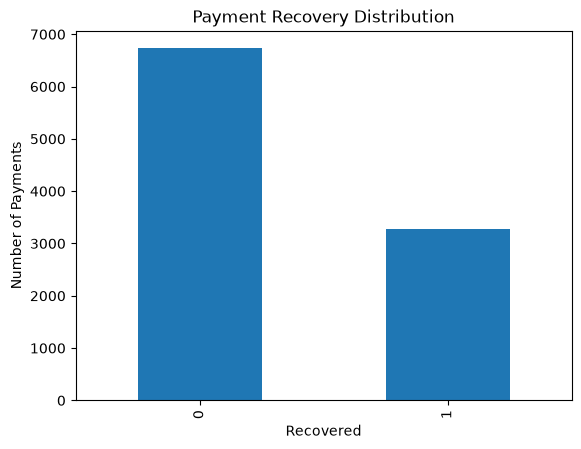

In [11]:
df["recovered"].value_counts().plot(kind="bar")

plt.title("Payment Recovery Distribution")
plt.xlabel("Recovered")
plt.ylabel("Number of Payments")
plt.show()

In [12]:
# numerical_features
numerical_features=[feature for feature in df.columns if df[feature].dtype != 'str']
print('Num of Numerical Features :', len(numerical_features))

Num of Numerical Features : 10


In [13]:
df[numerical_features].describe().T

,count,mean,std,min,25%,50%,75%,max
customer_age,10000.0,43.539400,14.911636,18.00,31.0000,43.000,56.0000,69.00
customer_tenure_months,10000.0,29.922000,17.014243,1.00,15.0000,30.000,45.0000,59.00
payment_amount,10000.0,1385.777442,1071.458748,95.31,676.7525,1087.300,1738.0125,11185.58
previous_payment_success_rate,10000.0,0.701463,0.173214,0.40,0.5500,0.700,0.8500,1.00
previous_failed_payments,10000.0,1.515500,1.235197,0.00,1.0000,1.000,2.0000,8.00
days_since_last_payment,10000.0,44.346800,25.685885,1.00,22.0000,44.000,66.0000,89.00
subscription_age_months,10000.0,23.994800,13.567667,1.00,12.0000,24.000,36.0000,47.00
customer_lifetime_value,10000.0,6861.641602,6370.489372,241.02,2912.6975,4986.585,8609.6200,92119.43
previous_recovery_count,10000.0,0.791500,0.890453,0.00,0.0000,1.000,1.0000,6.00
recovered,10000.0,0.327000,0.469141,0.00,0.0000,0.000,1.0000,1.00


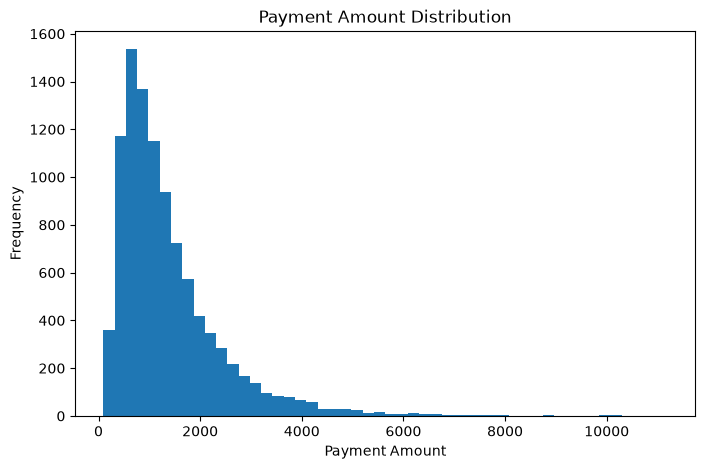

In [14]:
plt.figure(figsize=(8, 5))

plt.hist(df["payment_amount"], bins=50)

plt.title("Payment Amount Distribution")
plt.xlabel("Payment Amount")
plt.ylabel("Frequency")

plt.show()

##  Recovery rate by failure reason

In [15]:
recovery_by_reason = (
    df.groupby("failure_reason")["recovered"]
      .mean()
      .sort_values(ascending=False)
)

recovery_by_reason

failure_reason
network_error         0.454905
bank_error            0.414293
insufficient_funds    0.290775
card_declined         0.249179
expired_card          0.248473
Name: recovered, dtype: float64

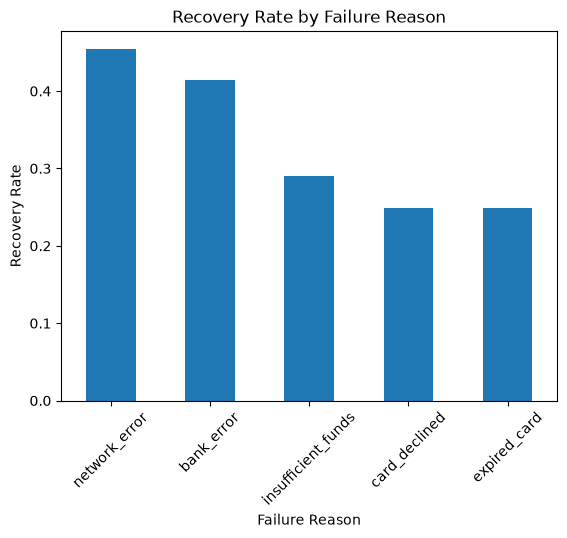

In [16]:
recovery_by_reason.plot(kind="bar")

plt.title("Recovery Rate by Failure Reason")
plt.xlabel("Failure Reason")
plt.ylabel("Recovery Rate")

plt.xticks(rotation=45)
plt.show()

## Recovery rate by payment method

In [17]:
recovery_by_method = (
    df.groupby("payment_method")["recovered"]
      .mean()
      .sort_values(ascending=False)
)

recovery_by_method

payment_method
wallet        0.351209
upi           0.331641
card          0.324155
netbanking    0.301158
Name: recovered, dtype: float64

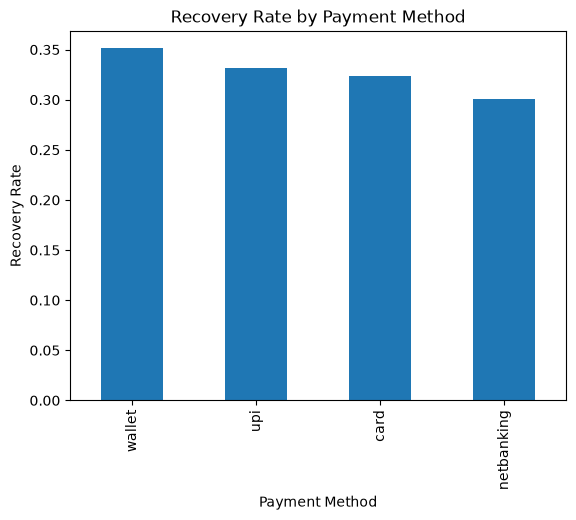

In [18]:
recovery_by_method.plot(kind="bar")

plt.title("Recovery Rate by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Recovery Rate")

plt.show()

## Previous payment reliability


In [19]:
df.groupby("recovered")["previous_payment_success_rate"].mean()

recovered
0    0.678771
1    0.748165
Name: previous_payment_success_rate, dtype: float64

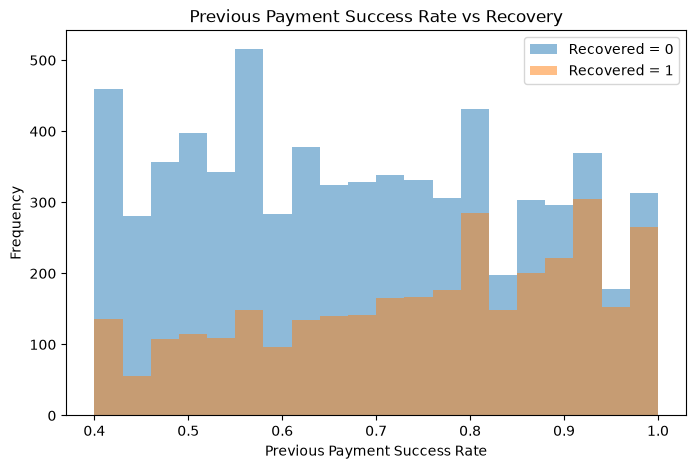

In [20]:
plt.figure(figsize=(8, 5))

for value in [0, 1]:
    subset = df[df["recovered"] == value]
    plt.hist(
        subset["previous_payment_success_rate"],
        bins=20,
        alpha=0.5,
        label=f"Recovered = {value}"
    )

plt.xlabel("Previous Payment Success Rate")
plt.ylabel("Frequency")
plt.title("Previous Payment Success Rate vs Recovery")
plt.legend()

plt.show()

In [21]:
df.groupby("recovered")["previous_failed_payments"].mean()

recovered
0    1.652749
1    1.233028
Name: previous_failed_payments, dtype: float64

In [22]:
df.groupby("recovered")["previous_recovery_count"].mean()

recovered
0    0.75156
1    0.87370
Name: previous_recovery_count, dtype: float64

### Correlation

In [23]:
correlation = df[numerical_features].corr()
correlation.sort_values(by="recovered", ascending=False)

,customer_age,customer_tenure_months,payment_amount,previous_payment_success_rate,previous_failed_payments,days_since_last_payment,subscription_age_months,customer_lifetime_value,previous_recovery_count,recovered
recovered,-0.001842,0.108217,-0.023081,0.187950,-0.159415,-0.190363,-0.005955,0.018552,0.064350,1.000000
previous_payment_success_rate,-0.008561,-0.011924,-0.003780,1.000000,-0.015782,-0.001932,0.005120,-0.022881,-0.001368,0.187950
customer_tenure_months,-0.005020,1.000000,0.014196,-0.011924,0.008528,0.004498,-0.002199,-0.019384,-0.004011,0.108217
previous_recovery_count,0.005398,-0.004011,0.002378,-0.001368,-0.006563,0.019371,0.008006,0.002612,1.000000,0.064350
customer_lifetime_value,0.004472,-0.019384,-0.027687,-0.022881,0.004465,0.025729,-0.004358,1.000000,0.002612,0.018552
customer_age,1.000000,-0.005020,-0.010145,-0.008561,0.003700,-0.007792,0.011945,0.004472,0.005398,-0.001842
subscription_age_months,0.011945,-0.002199,-0.021724,0.005120,0.009577,0.009335,1.000000,-0.004358,0.008006,-0.005955
payment_amount,-0.010145,0.014196,1.000000,-0.003780,0.003131,-0.001038,-0.021724,-0.027687,0.002378,-0.023081
previous_failed_payments,0.003700,0.008528,0.003131,-0.015782,1.000000,-0.000043,0.009577,0.004465,-0.006563,-0.159415
days_since_last_payment,-0.007792,0.004498,-0.001038,-0.001932,-0.000043,1.000000,0.009335,0.025729,0.019371,-0.190363


## Feature Engg


In [24]:
df["failure_rate"] = (
    1 - df["previous_payment_success_rate"]
)

In [25]:
df["customer_reliability_score"] = (
    df["previous_payment_success_rate"] *
    np.log1p(df["customer_tenure_months"])
)

In [26]:
df["recovery_history"] = (
    df["previous_recovery_count"] /
    (df["previous_failed_payments"] + 1)
)

In [27]:
#New features
df[
    [
        "failure_rate",
        "customer_reliability_score",
        "recovery_history"
    ]
].describe()

,failure_rate,customer_reliability_score,recovery_history
count,10000.000000,10000.000000,10000.000000
mean,0.298537,2.241277,0.410011
std,0.173214,0.792928,0.566638
min,0.000000,0.277259,0.000000
25%,0.150000,1.664887,0.000000
50%,0.300000,2.209118,0.250000
75%,0.450000,2.828528,0.500000
max,0.600000,4.094345,5.000000


In [28]:
df.head()

,customer_age,customer_tenure_months,payment_amount,previous_payment_success_rate,previous_failed_payments,days_since_last_payment,payment_method,failure_reason,subscription_age_months,customer_lifetime_value,previous_recovery_count,recovered,failure_rate,customer_reliability_score,recovery_history
0,56,11,1505.74,0.49,1,10,upi,card_declined,22,12488.96,1,0,0.51,1.217604,0.5
1,69,22,1557.84,0.53,5,86,card,insufficient_funds,22,2041.51,3,0,0.47,1.661812,0.5
2,46,54,465.31,0.89,0,68,upi,network_error,30,20882.40,0,0,0.11,3.566527,0.0
3,32,24,721.96,0.84,0,43,upi,network_error,7,2198.89,2,1,0.16,2.703856,2.0
4,60,1,951.13,0.52,1,87,upi,card_declined,6,1150.94,0,0,0.48,0.360437,0.0


In [29]:
df.to_csv("../data/payments_processed.csv", index=False)

In [30]:
df.shape

(10000, 15)